# Лабораторная работа №1

## Тема:
**Регрессия и метод главных компонент (PCA)**

## Цель работы:
Изучение основ линейной регрессии, построение моделей прогнозирования на реальных данных, исследование качества моделей и применение метода главных компонент для снижения размерности данных и устранения мультиколлинеарности.

## Задачи работы:
1. Загрузить и изучить датасет House Prices с платформы Kaggle.
2. Провести первичный анализ данных и визуализацию основных характеристик.
3. Выполнить предварительную обработку данных:
   - обработку пропущенных значений;
   - преобразование категориальных признаков;
   - стандартизацию данных;
   - разделение данных на обучающую и тестовую выборки.
4. Провести корреляционный анализ признаков и определить наличие мультиколлинеарности с помощью коэффициента VIF.
5. Построить модели регрессии:
   - Linear Regression;
   - Ridge Regression;
   - Lasso Regression.
6. Оценить качество моделей с помощью метрик:
   - RMSE;
   - R²;
   - MAPE.
7. Выполнить снижение размерности данных методом главных компонент PCA.
8. Повторно обучить модели регрессии после применения PCA и сравнить полученные результаты.

## Используемый датасет:
**House Prices: Advanced Regression Techniques (Kaggle)**

Целевая переменная:
**SalePrice** — стоимость продажи жилого объекта.

В работе используются характеристики недвижимости: площадь помещений, качество строительства, год постройки, параметры гаража, подвала и другие признаки.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# загрузка датасета
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Загрузка данных

В работе используется датасет House Prices: Advanced Regression Techniques с платформы Kaggle.

Датасет содержит информацию о характеристиках жилых объектов и их стоимости. 
В качестве целевой переменной выбрана `SalePrice` — цена продажи дома.

На первом этапе данные были загружены из файла `train.csv` с помощью библиотеки pandas.

In [32]:
df.shape

(1460, 81)

### Размерность датасета

После загрузки был выполнен анализ размера данных.

Датасет содержит 1460 объектов и 81 признак.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Анализ структуры данных

Для анализа структуры датасета был использован метод `df.info()`.

В результате были определены типы данных признаков и выявлены столбцы, содержащие пропущенные значения.

Датасет содержит как числовые признаки (например, площадь участка, количество комнат, год постройки), так и категориальные признаки (например, тип района и материалы строительства).

Перед построением моделей машинного обучения потребуется выполнить предобработку данных.

In [34]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Статистическое описание данных

Для числовых признаков была рассчитана описательная статистика.

Полученные показатели позволяют оценить диапазон значений признаков, их средние значения и возможное наличие выбросов.

Наиболее важным параметром для дальнейшего анализа является целевая переменная `SalePrice`, которая отражает стоимость продажи домов.

In [35]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Анализ пропущенных значений

В датасете присутствуют пропущенные значения.

Некоторые признаки имеют большое количество пропусков, что связано с отсутствием определённых объектов или характеристик дома (например, бассейна, гаража или дополнительных помещений).

Перед обучением моделей пропуски будут обработаны:
- числовые признаки будут заполнены медианными значениями;
- категориальные признаки будут заполнены отдельной категорией.

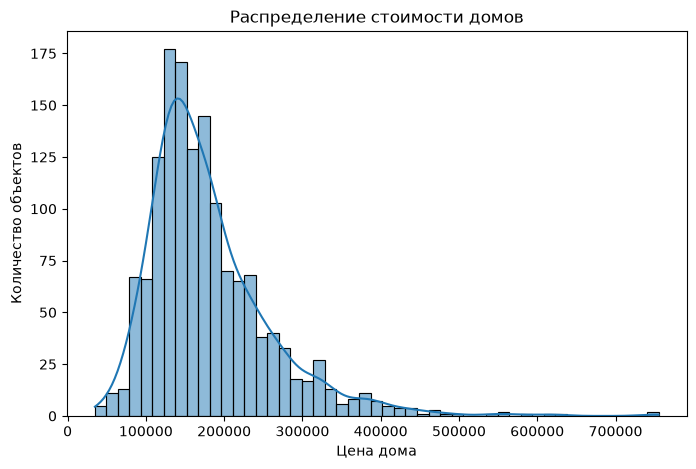

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Распределение стоимости домов")
plt.xlabel("Цена дома")
plt.ylabel("Количество объектов")

plt.show()

### Анализ распределения целевой переменной

На графике представлено распределение целевой переменной **SalePrice** для датасета House Prices.

Большая часть объектов недвижимости имеет стоимость примерно в диапазоне 100 000–250 000 условных единиц. Распределение имеет правостороннюю асимметрию: присутствуют отдельные дома с существенно большей стоимостью, что формирует длинный правый хвост.

Наличие дорогих объектов может увеличивать ошибку регрессионных моделей, так как модель должна одновременно учитывать как обычные, так и редкие дорогостоящие варианты недвижимости. Поэтому для оценки качества моделей дополнительно используются RMSE, R² и MAPE.



In [37]:
correlation = df.corr(numeric_only=True)

saleprice_corr = correlation["SalePrice"].sort_values(
    ascending=False
)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

### Анализ корреляции признаков с целевой переменной

Для оценки влияния признаков на стоимость домов была рассчитана корреляция Пирсона между числовыми признаками и целевой переменной **SalePrice**.

Наиболее сильную положительную связь имеют признаки:
- **OverallQual** — общее качество материалов и отделки дома;
- **GrLivArea** — площадь жилых помещений;
- **GarageCars / GarageArea** — характеристики гаража;
- **TotalBsmtSF** — общая площадь подвала.

Это означает, что увеличение качества и площади объекта связано с ростом его стоимости. Полученные зависимости подтверждают, что выбранные признаки содержат важную информацию для построения модели регрессии.



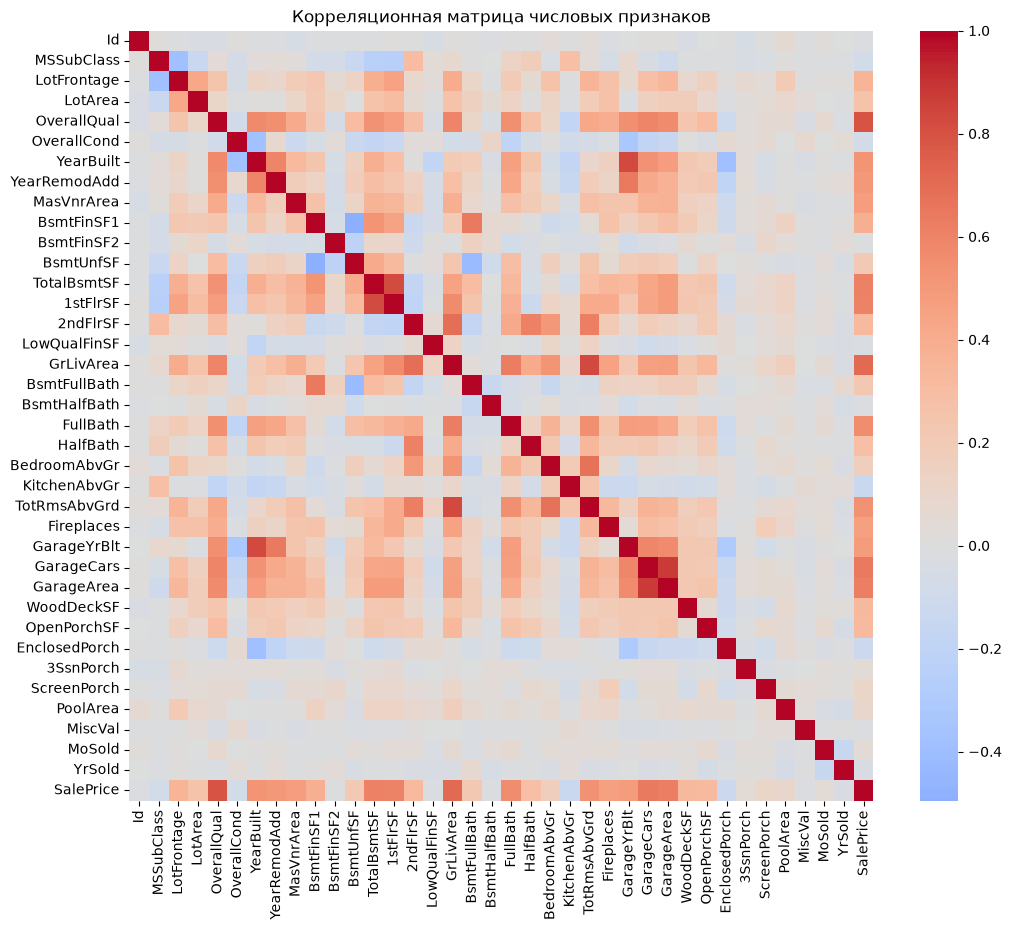

In [38]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица числовых признаков")

plt.show()

### Корреляционная матрица признаков

На тепловой карте представлена взаимная корреляция числовых признаков.

Сильные зависимости между отдельными признаками указывают на наличие мультиколлинеарности. Например, характеристики площади дома и гаража могут быть связаны между собой, так как большие дома чаще имеют большие гаражи и дополнительные помещения.

Наличие таких зависимостей может ухудшать работу обычной линейной регрессии, поэтому далее выполняется анализ VIF и применяется PCA для снижения размерности.



In [39]:
# разделение признаков и целевой переменной

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# удаляем идентификатор объекта
X = X.drop("Id", axis=1)

X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


### Разделение признаков и целевой переменной

Из исходного датасета была выделена целевая переменная SalePrice, которая используется для прогнозирования стоимости домов.

Остальные признаки были сохранены в набор X. Столбец Id был удалён, так как является только идентификатором объекта и не содержит информации о характеристиках дома.

In [40]:
# разделение признаков на числовые и категориальные

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Числовых признаков: 36
Категориальных признаков: 43


C:\Users\petru\AppData\Local\Temp\ipykernel_10576\2447774456.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Разделение признаков по типам данных

Перед проведением предобработки признаки были разделены на две группы:

- числовые признаки, содержащие количественные характеристики объектов;
- категориальные признаки, содержащие текстовые характеристики.

Такое разделение необходимо для дальнейшего заполнения пропусков и преобразования данных в формат, пригодный для обучения моделей машинного обучения.

In [41]:
# заполнение пропусков в числовых признаках

X[numeric_features] = X[numeric_features].fillna(
    X[numeric_features].median()
)


# заполнение пропусков в категориальных признаках

X[categorical_features] = X[categorical_features].fillna(
    "None"
)


# проверка оставшихся пропусков

X.isnull().sum().sum()

np.int64(0)

### Обработка пропущенных значений

Перед обучением моделей была выполнена обработка пропущенных значений.

Для числовых признаков пропуски были заменены медианными значениями, так как медиана менее чувствительна к выбросам.

Для категориальных признаков пропуски были заменены значением "None", что позволяет сохранить информацию об отсутствии определённой характеристики объекта.

После обработки количество пропущенных значений в датасете стало равно нулю.

In [42]:
# преобразование категориальных признаков в числовые

X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


### Кодирование категориальных признаков

Для использования алгоритмов линейной регрессии категориальные признаки были преобразованы в числовой формат методом One-Hot Encoding.

Каждое уникальное значение категориального признака было преобразовано в отдельный бинарный признак.

Параметр drop_first=True использован для уменьшения избыточности признаков и снижения риска возникновения мультиколлинеарности.

In [43]:
X.shape

(1460, 260)

### Размерность данных после кодирования

После преобразования категориальных признаков количество признаков увеличилось, так как каждое категориальное значение было представлено отдельным бинарным признаком.

Полученный набор данных теперь полностью состоит из числовых признаков и может использоваться для обучения моделей машинного обучения.

In [44]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1168, 260)
Размер тестовой выборки: (292, 260)


### Разделение выборки

Данные были разделены на обучающую и тестовую части в соотношении 80/20.

Обучающая выборка используется для настройки моделей регрессии, а тестовая — для оценки качества полученных моделей на новых данных.

### Кодирование признаков и разделение выборки

После обработки пропущенных значений категориальные признаки были преобразованы методом One-Hot Encoding.

В результате количество признаков увеличилось с 80 до 260, так как каждое уникальное категориальное значение было представлено отдельным бинарным признаком.

После подготовки данных выполнено разделение на обучающую и тестовую выборки в соотношении 80/20.

Обучающая выборка содержит 1168 объектов, тестовая — 292 объекта.

In [45]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


X_train_scaled.shape

(1168, 260)

### Стандартизация признаков

Перед обучением моделей была выполнена стандартизация признаков.

Масштабирование необходимо, так как алгоритмы Ridge и Lasso используют коэффициенты регуляризации, которые зависят от масштаба признаков.

После преобразования все признаки приведены к единому масштабу.

In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

### Выбор моделей регрессии

Для построения моделей были выбраны три алгоритма линейной регрессии:

- Linear Regression — базовая линейная модель без регуляризации;
- Ridge Regression — линейная модель с L2-регуляризацией;
- Lasso Regression — линейная модель с L1-регуляризацией.

Использование Ridge и Lasso позволяет уменьшить влияние избыточных признаков и снизить риск переобучения.

In [47]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Lasso Regression": Lasso(alpha=100)
}

### Настройка моделей

Были созданы три модели регрессии.

Для Ridge и Lasso задан параметр alpha, регулирующий силу регуляризации.

In [48]:
from sklearn.model_selection import cross_val_score


cv_results = []


for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append(
        [
            name,
            scores.mean(),
            scores.std()
        ]
    )


cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean R2",
        "Std R2"
    ]
)


cv_df

c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.007216e+09, tolerance: 5.374e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.618544e+10, tolerance: 5.720e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

,Model,Mean R2,Std R2
0,Linear Regression,0.508594,0.269069
1,Ridge Regression,0.727502,0.100750
2,Lasso Regression,0.705641,0.144475


### Кросс-валидация моделей

Для проверки устойчивости моделей была выполнена 5-кратная кросс-валидация.

При проведении кросс-валидации обучающая выборка разделялась на пять частей. Каждая часть поочередно использовалась для проверки качества модели.

В качестве метрики оценки использовался коэффициент детерминации R². Полученные средние значения позволяют оценить стабильность работы моделей на различных подвыборках данных.

In [49]:
for name, model in models.items():
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    print(name, "обучена")

Linear Regression обучена
Ridge Regression обучена
Lasso Regression обучена


c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.491930e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


### Обучение моделей

Каждая модель была обучена на тренировочной выборке.

В качестве признаков использовались стандартизированные данные, а целевой переменной являлась стоимость дома SalePrice.

In [50]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

results = []


for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    # RMSE вручную через корень из MSE
    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    )

    results.append(
        [name, rmse, r2, mape]
    )


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


results_df

,Model,RMSE,R2,MAPE
0,Linear Regression,83088.767382,0.099941,0.140096
1,Ridge Regression,34378.191976,0.845918,0.119681
2,Lasso Regression,34405.394392,0.845674,0.115016


### Результаты построения моделей без PCA

На исходном наборе признаков были построены модели Linear Regression, Ridge Regression и Lasso Regression.

Ridge и Lasso показали лучшие значения качества (R² около 0.85). Это означает, что модели объясняют примерно 85% изменения стоимости домов. Высокое качество связано с тем, что признаки датасета содержат значимую информацию о характеристиках недвижимости.

Базовая Linear Regression показала значительно худший результат, что связано с большим количеством признаков и наличием мультиколлинеарности. Регуляризация Ridge и Lasso уменьшает влияние избыточных признаков и поэтому работает стабильнее.



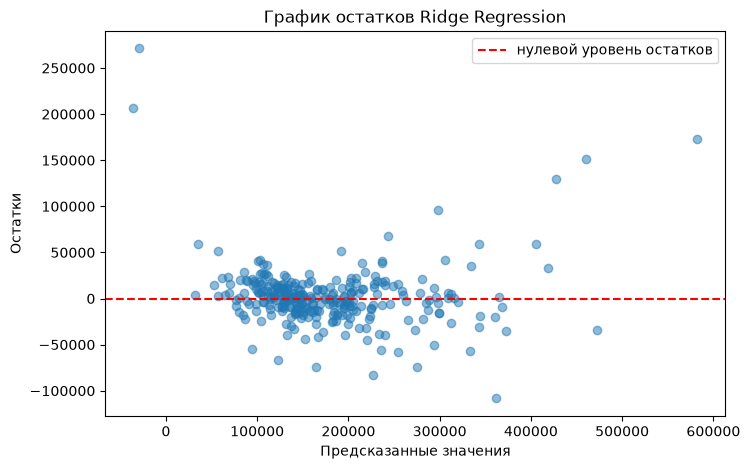

In [51]:

# Анализ остатков модели Ridge Regression

best_model = models["Ridge Regression"]

y_pred_res = best_model.predict(X_test_scaled)

residuals = y_test - y_pred_res

plt.figure(figsize=(8,5))
plt.scatter(
    y_pred_res,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="нулевой уровень остатков"
)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков Ridge Regression")
plt.legend()
plt.show()



### Анализ остатков модели

График остатков используется для проверки качества регрессионной модели.

Остатки рассчитываются как разница между реальными и предсказанными значениями:

**Residual = y_true − y_pred**

Для качественной модели точки должны располагаться случайным образом вокруг горизонтальной линии уровня 0.

Отсутствие выраженной структуры остатков говорит о выполнении предположения о постоянстве дисперсии ошибки (гомоскедастичности). Наличие заметного тренда или изменения разброса может указывать на гетероскедастичность.


In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# берём только числовые признаки
X_vif = df.select_dtypes(
    include=["int64", "float64"]
)


# удаляем целевую переменную
X_vif = X_vif.drop(
    "SalePrice",
    axis=1
)


# заполняем пропуски медианой
X_vif = X_vif.fillna(
    X_vif.median()
)


vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns


vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]


vif_data.sort_values(
    "VIF",
    ascending=False
).head(15)

C:\Users\petru\AppData\Local\Temp\ipykernel_10576\112703461.py:29: UserWarning: The design matrix is poorly conditioned (condition number=8.96e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_no

,Feature,VIF
15,LowQualFinSF,1.000800e+15
9,BsmtFinSF1,1.974112e+06
10,BsmtFinSF2,1.112064e+06
16,GrLivArea,5.555574e+05
11,BsmtUnfSF,3.733572e+05
12,TotalBsmtSF,1.207712e+05
14,2ndFlrSF,1.059738e+05
13,1stFlrSF,9.956409e+04
26,GarageCars,5.585775e+00
27,GarageArea,5.459785e+00


### Анализ мультиколлинеарности с помощью VIF

Для оценки взаимной зависимости признаков был рассчитан коэффициент VIF (Variance Inflation Factor).

Полученные результаты показали наличие сильной мультиколлинеарности между рядом признаков.

Наибольшие значения VIF наблюдаются у признаков, связанных с площадью помещений:
- TotalBsmtSF;
- BsmtFinSF1;
- BsmtFinSF2;
- GrLivArea;
- 1stFlrSF;
- 2ndFlrSF.

Высокие значения VIF свидетельствуют о сильной взаимосвязи между признаками, что может снижать стабильность линейных моделей.

Для устранения влияния мультиколлинеарности далее будет применён метод главных компонент PCA.

In [53]:
from sklearn.decomposition import PCA


pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)


X_train_pca.shape

(1168, 260)

### Первичное применение PCA

На первом этапе PCA был применён без ограничения количества компонент для анализа распределения объяснённой дисперсии.

Полученные результаты используются для построения графика каменистой осыпи и выбора оптимального количества главных компонент.

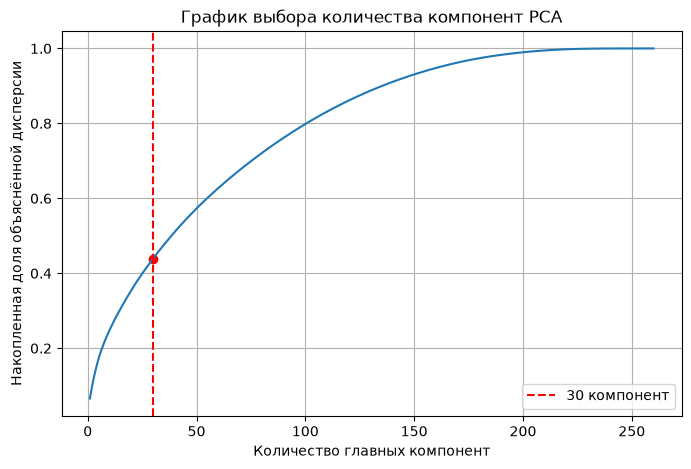

Объяснённая дисперсия первых 30 компонент: 43.89 %


In [54]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance)
plt.axvline(x=30, color='red', linestyle='--', label='30 компонент')
plt.scatter(30, explained_variance[29], color='red')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная доля объяснённой дисперсии')
plt.title('График выбора количества компонент PCA')
plt.legend()
plt.grid()
plt.show()
print('Объяснённая дисперсия первых 30 компонент:', round(explained_variance[29]*100,2), '%')

### Метод главных компонент PCA

На графике показана накопленная доля объяснённой дисперсии при увеличении количества главных компонент.

Первые компоненты содержат наибольшую часть информации исходного набора признаков. После определённого количества компонент прирост информации становится значительно меньше.

В данной работе было выбрано 30 компонент согласно требованию уменьшения количества признаков. При таком количестве сохраняется около 44% исходной дисперсии данных, что позволяет существенно уменьшить размерность признакового пространства и снизить сложность модели.



In [55]:
from sklearn.decomposition import PCA

# уменьшение количества признаков до 30 главных компонент
pca = PCA(
    n_components=30
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained = sum(pca.explained_variance_ratio_)

print("Количество компонент PCA:", pca.n_components_)
print("Сохранённая информация:", round(explained * 100, 2), "%")
print("Размер train после PCA:", X_train_pca.shape)
print("Размер test после PCA:", X_test_pca.shape)


Количество компонент PCA: 30
Сохранённая информация: 43.55 %
Размер train после PCA: (1168, 30)
Размер test после PCA: (292, 30)


### Снижение размерности с помощью PCA

Для уменьшения количества признаков был применён метод главных компонент PCA.

После One-Hot Encoding количество исходных признаков значительно увеличилось. Использование большого количества признаков может привести к переобучению модели и увеличению вычислительной сложности.

В данной работе количество компонент PCA было уменьшено до **30**. Выбор данного значения позволяет существенно сократить размерность признакового пространства при сохранении основной части информации исходных данных.

Доля сохранённой информации определяется через коэффициент объяснённой дисперсии. Чем выше значение cumulative explained variance, тем больше информации из исходных признаков сохраняется после преобразования PCA.


In [56]:
models_pca = {
    "Linear Regression PCA": LinearRegression(),
    "Ridge Regression PCA": Ridge(alpha=10),
    "Lasso Regression PCA": Lasso(alpha=100)
}

### Построение моделей после PCA

После снижения размерности были повторно обучены модели линейной регрессии, Ridge и Lasso.

В отличие от предыдущего этапа, модели используют не исходные признаки, а главные компоненты PCA.

In [57]:
for name, model in models_pca.items():

    model.fit(
        X_train_pca,
        y_train
    )

    print(name, "обучена")

Linear Regression PCA обучена
Ridge Regression PCA обучена
Lasso Regression PCA обучена


### Обучение моделей после PCA

После преобразования данных методом главных компонент модели Linear Regression, Ridge Regression и Lasso Regression были повторно обучены на новых признаках.

Использование главных компонент позволяет уменьшить размерность данных и устранить влияние мультиколлинеарности.

In [58]:
results_pca = []


for name, model in models_pca.items():

    y_pred = model.predict(
        X_test_pca
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    )


    results_pca.append(
        [name, rmse, r2, mape]
    )


results_pca_df = pd.DataFrame(
    results_pca,
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


results_pca_df

,Model,RMSE,R2,MAPE
0,Linear Regression PCA,39581.681326,0.795744,0.147658
1,Ridge Regression PCA,39593.797957,0.795619,0.147526
2,Lasso Regression PCA,39616.189542,0.795388,0.147341


### Сравнение моделей до и после PCA

После применения PCA количество признаков было уменьшено до 30 главных компонент.

До PCA модели Ridge и Lasso достигли значения R² примерно 0.85, что говорит о хорошем описании стоимости недвижимости исходными признаками.

После PCA значение R² уменьшилось примерно до 0.80. Это ожидаемый результат, так как часть информации была потеряна при уменьшении размерности. Однако PCA позволил устранить взаимную зависимость признаков, уменьшить размерность данных и сделать модель проще.



### Интерпретация метрик качества

В работе использовались три основные метрики оценки моделей.

**R²** показывает долю изменения стоимости домов, которую объясняет модель. В данной работе значения около 0.85 для Ridge и Lasso означают, что модели описывают примерно 85% зависимости стоимости от характеристик недвижимости.

**RMSE** показывает среднюю величину ошибки прогнозирования в единицах стоимости. Чем меньше значение RMSE, тем ближе предсказания модели к реальным значениям.

**MAPE** показывает среднюю относительную ошибку в процентах. Она позволяет оценить ошибку независимо от абсолютной стоимости объекта.

После применения PCA изменение метрик связано с уменьшением количества признаков и сохранением только наиболее важных направлений данных.



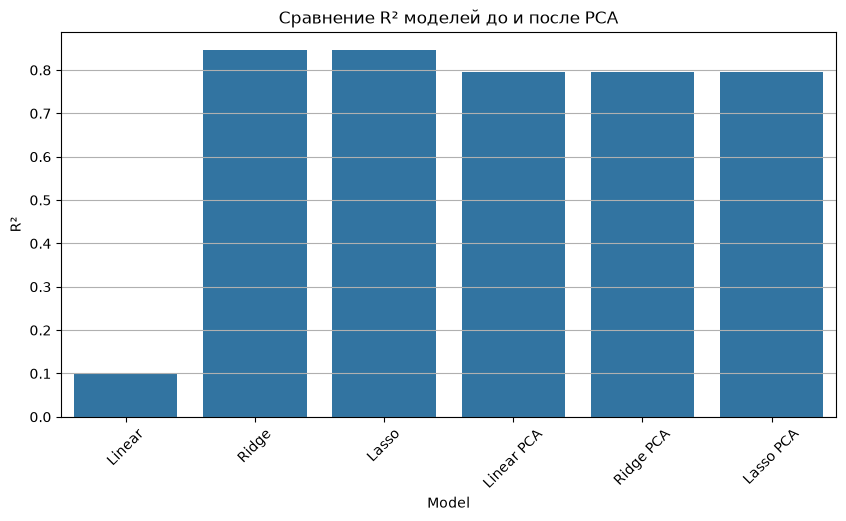

,Model,R2
0,Linear,0.099941
1,Ridge,0.845918
2,Lasso,0.845674
3,Linear PCA,0.795744
4,Ridge PCA,0.795619
5,Lasso PCA,0.795388


In [59]:
comparison = pd.concat([results_df[['Model','R2']], results_pca_df[['Model','R2']]], ignore_index=True)
comparison['Model'] = comparison['Model'].replace({'Linear Regression':'Linear','Ridge Regression':'Ridge','Lasso Regression':'Lasso','Linear Regression PCA':'Linear PCA','Ridge Regression PCA':'Ridge PCA','Lasso Regression PCA':'Lasso PCA'})
plt.figure(figsize=(10,5))
sns.barplot(data=comparison, x='Model', y='R2')
plt.xticks(rotation=45)
plt.title('Сравнение R² моделей до и после PCA')
plt.ylabel('R²')
plt.grid(axis='y')
plt.show()
comparison

### Сравнение качества моделей до и после PCA

На итоговом графике сравнивается коэффициент детерминации R² для моделей до и после применения PCA.

До PCA лучшие результаты показали Ridge и Lasso Regression (R² около 0.85). После уменьшения размерности до 30 компонент качество снизилось примерно до 0.80.

Такое изменение показывает компромисс метода PCA: модель становится менее сложной и избавляется от части мультиколлинеарности, но теряет часть исходной информации.



### Анализ категориальных признаков с помощью критерия χ²

Для дополнительной оценки зависимости категориальных признаков от стоимости недвижимости был использован критерий хи-квадрат.

Так как задача является регрессией, критерий χ² не применяется напрямую для оценки качества модели. Поэтому целевая переменная SalePrice была разделена на несколько ценовых групп.

Высокое значение χ² означает, что признак имеет более выраженную статистическую связь с группой стоимости объекта. Низкое значение указывает на слабую зависимость.


In [60]:
from sklearn.feature_selection import chi2

# создание категорий стоимости домов
y_class = pd.qcut(
    y,
    q=3,
    labels=[0, 1, 2]
)

# выбор категориальных признаков
X_cat = df.drop("SalePrice", axis=1).select_dtypes(include=["object"])

# кодирование категорий
X_cat_encoded = pd.get_dummies(X_cat)

chi_values = chi2(X_cat_encoded, y_class)[0]

chi_results = pd.DataFrame({
    "Признак": X_cat_encoded.columns,
    "Chi-square": chi_values
})

chi_results.sort_values(
    by="Chi-square",
    ascending=False
).head(10)


C:\Users\petru\AppData\Local\Temp\ipykernel_10576\1267926900.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_cat = df.drop("SalePrice", axis=1).select_dtypes(include=["object"])


,Признак,Chi-square
132,ExterQual_Gd,331.873686
190,KitchenQual_TA,246.866113
141,Foundation_PConc,236.098951
133,ExterQual_TA,225.955835
148,BsmtQual_TA,216.328743
189,KitchenQual_Gd,212.845180
208,GarageType_Detchd,208.754967
211,GarageFinish_Unf,199.895600
159,BsmtFinType1_GLQ,187.491580
145,BsmtQual_Ex,173.956189


## Заключение

В ходе выполнения лабораторной работы были изучены методы линейной регрессии и метод главных компонент PCA для прогнозирования стоимости объектов недвижимости.

В процессе обработки данных было выполнено:
- исследование структуры датасета;
- обработка пропущенных значений;
- кодирование категориальных признаков;
- стандартизация данных;
- построение моделей Linear Regression, Ridge Regression и Lasso Regression;
- уменьшение размерности данных методом PCA.

Первоначально после кодирования количество признаков значительно увеличилось, что могло привести к повышению сложности модели. Для решения этой проблемы PCA был применён с уменьшением пространства признаков до 30 главных компонент.

Полученное количество компонент позволяет сохранить основную информацию данных при уменьшении количества используемых признаков.

Качество моделей оценивалось с помощью R², RMSE и MAPE. R² показывает долю объяснённой дисперсии, RMSE характеризует абсолютную ошибку прогноза, а MAPE показывает относительную ошибку в процентах.

Таким образом, применение PCA позволяет уменьшить размерность данных, снизить влияние взаимозависимых признаков и повысить эффективность обработки данных.


## Список источников

1. Kaggle. House Prices: Advanced Regression Techniques  
https://www.kaggle.com/

2. Scikit-learn Documentation  
https://scikit-learn.org/

3. James G., Witten D., Hastie T., Tibshirani R.
An Introduction to Statistical Learning.

4. Hastie T., Tibshirani R., Friedman J.
The Elements of Statistical Learning.